In [1]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [21]:
# setup
df = pd.read_csv('../../data/processed/neighborhood_equity_model.csv')
# set neighborhood as index so removed from feature columns
df.set_index("neighborhood", inplace=True)

In [24]:
# training and test data

feature_columns = ['Median Household Income', 'program_count_per1000', 'percent_bachelors', 'Percent White']
# select feature columns and scale
X = df[feature_columns]

# target column - unscaled
target_col = 'avgOverallEquityScore'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

## Descriptive OLS

In [25]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     43.73
Date:                Fri, 30 May 2025   Prob (F-statistic):           1.12e-18
Time:                        19:03:01   Log-Likelihood:                -47.933
No. Observations:                  78   AIC:                             105.9
Df Residuals:                      73   BIC:                             117.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Predictive Model

In [26]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.8794562518216773
RMSE: 0.3078595688494893


## Model Plot

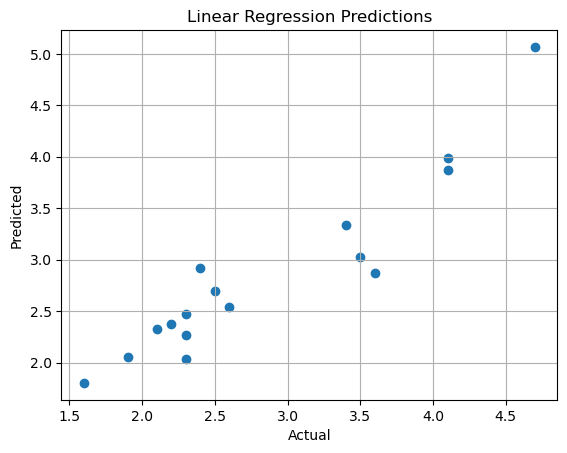

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.grid(True)
plt.show()

## With Poverty Rate

In [29]:
# training and test data

feature_columns = ['Median Household Income', 'program_count_per1000', 'percent_bachelors', 'Percent White','Percent Living in Poverty']
# select feature columns and scale
X = df[feature_columns]

# target column - unscaled
target_col = 'avgOverallEquityScore'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [30]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     35.03
Date:                Fri, 30 May 2025   Prob (F-statistic):           5.43e-18
Time:                        19:34:39   Log-Likelihood:                -47.517
No. Observations:                  78   AIC:                             107.0
Df Residuals:                      72   BIC:                             121.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [31]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.8866175227697458
RMSE: 0.2985748906338157


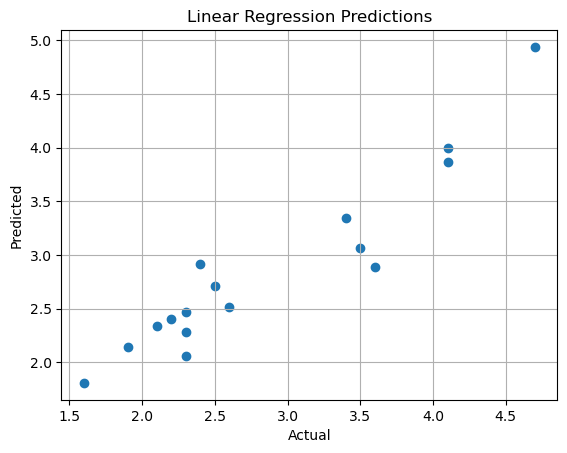

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.grid(True)
plt.show()

## With Percent Hispanic and HS Degree

In [36]:
# training and test data

feature_columns = ['Median Household Income', 'program_count_per1000', 'percent_bachelors', 'Percent White','Percent Living in Poverty','percent_less_hs', 'Percent Hispanic']
# select feature columns and scale
X = df[feature_columns]

# target column - unscaled
target_col = 'avgOverallEquityScore'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [37]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     25.84
Date:                Fri, 30 May 2025   Prob (F-statistic):           4.42e-17
Time:                        19:47:43   Log-Likelihood:                -45.831
No. Observations:                  78   AIC:                             107.7
Df Residuals:                      70   BIC:                             126.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [38]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.8986948401764887
RMSE: 0.28222539803274804


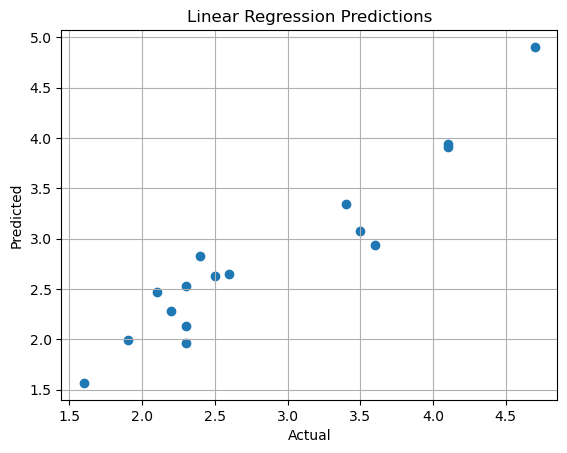

In [40]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.grid(True)
plt.show()